I've run two iterations of the FEAST model this week: the first one was a working version of the code that we had from RTI; the second one was a short run of a re-written version of the FEAST code that corrects some weird issues, re-workes the LDAR Programs, and sets up a simple attempt at a satellite program. This code is to work through Loading the JSON files and figuing out 1. how to pull out the info we need, 2. confirm that we got the LDAR programs set up correctly, metadatawise. 

In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import json
with open('Run_Results/realization0.json') as f:
    res = json.load(f)

Ah - The Jupyternotebook runs out of the file it's saved in. So it can't pull from 'EPA_Trial_Run/...', it has to run through 'Run_Results...' Great. Lets also load in the 

In [29]:
import json
with open('Run_Results_Rewrite/realization2.json') as f:
    runresults = json.load(f)

In [9]:
runresults.keys()

dict_keys(['quarterly_ogi', 'periodic', 'periodic_annual', 'satellite', 'satellite_annual', 'Null', 'time'])

re-making the timeseries plot from the original tutorial

In [26]:
# The color set defined here is the Tableau 10 color set.
color_set = np.array([
    [78, 121, 167],
    [242, 142,  43],
    [225,  87,  89],
    [118, 183, 178],
    [89, 161,  79],
    [237, 201, 72],
    [176, 122, 161],
    [255, 157, 167],
    [156, 117,  95],
    [186, 176, 172]
]) /255


quarterly_ogi
periodic
periodic_annual
satellite
satellite_annual
no LDAR


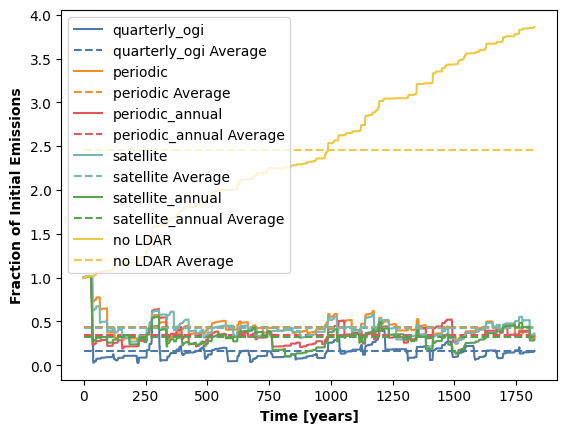

In [30]:
fig = plt.figure()
ax = fig.add_subplot(111)
counter = -1
 
for i in runresults.keys():
    lab = i #set the legend 
    #skip time and also set null to no LDAR
    if i.lower() == "null":
        lab = "no LDAR"
    if i.lower() == "time":
        break
    counter += 1
    print(lab)
    ax.plot(np.array(range(0,runresults['time']['n_timesteps'])), 
            np.array(runresults[i]['emission timeseries']) / runresults["Null"]['emission timeseries'][0], 
            label=lab, color=color_set[counter])
    
    avg_emissions = np.mean(np.array(runresults[i]['emission timeseries'])  / runresults["Null"]['emission timeseries'][0])
    ax.plot([0,runresults['time']['n_timesteps']],np.array([avg_emissions, avg_emissions]), '--', label = lab + ' Average', color = color_set[counter])

    

plt.xlabel('Time [years]', fontweight = 'bold')
plt.ylabel('Fraction of Initial Emissions', fontweight = 'bold')
plt.legend(bbox_to_anchor=(1, 0.72))
plt.legend()

In [24]:
print (color_set[0])

[ 78 121 167]


Lets redo that same plot but with aboslute emissions...

quarterly_ogi
periodic
periodic_annual
satellite
satellite_annual
no LDAR


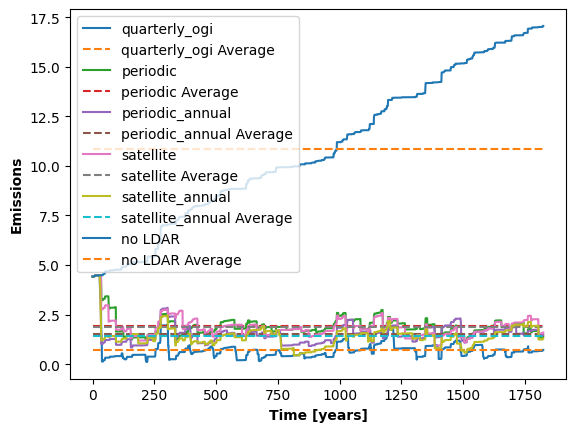

In [31]:
fig = plt.figure()
ax = fig.add_subplot(111)

 
for i in runresults.keys():
    lab = i #set the legend 
    #skip time and also set null to no LDAR
    if i.lower() == "null":
        lab = "no LDAR"
    if i.lower() == "time":
        break
    print(lab)
    ax.plot(np.array(range(0,runresults['time']['n_timesteps'])), 
            np.array(runresults[i]['emission timeseries']) , 
            label=lab)
    
    avg_emissions = np.mean(np.array(runresults[i]['emission timeseries']) )
    ax.plot([0,runresults['time']['n_timesteps']],np.array([avg_emissions, avg_emissions]), '--', label = lab + ' Average')

    

plt.xlabel('Time [years]', fontweight = 'bold')
plt.ylabel('Emissions', fontweight = 'bold')
plt.legend(bbox_to_anchor=(1, 0.72))
plt.legend()

Alright, thats all good - we can load different versions etc, but that's a single iterations version of the plot. What I /need/ are the average and variance of a bunch of different runs. To do that, I need to be able to load data into a multistructured data object...lets see how that works. Pulled Solution from: https://stackoverflow.com/questions/30539679/python-read-several-json-files-from-a-folder 

In [ ]:
import os, json
import pandas as pd

path_to_json = 'Run_Results_Rewrite/'
json_files = [pos_json for pos_json in os.listdir(path_to_json) if pos_json.endswith('.json')]
print(json_files) 

['realization0.json', 'realization10.json', 'realization12.json', 'realization14.json', 'realization16.json', 'realization18.json', 'realization2.json', 'realization4.json', 'realization6.json', 'realization8.json']


Okay, that pulled the JSON Files; order doesn't matter, so we just need to loop over and write them to a large file...

In [39]:
print(range(len(json_files)))

range(0, 10)


Just checking how to load JSON files here: 

In [ ]:
with open('Run_Results_Rewrite/realization2.json') as f:
    runresults = json.load(f)

In [48]:
check = json.load(open('Run_Results_Rewrite/realization2.json'))

Okay, so loop over your JSON files and load; we'll load one at a time. 

In [ ]:
em_results = pd.DataFrame(columns=df.keys())
em_results = em_results.drop(columns=['time'])

In [95]:
for i in range(len(json_files)):
    read_file = 'Run_Results_Rewrite/' + str(json_files[i])
    df = json.load(open(read_file))
    
    if i == 0: #on the first iteration create the catch file for all iterations. 
        em_results = pd.DataFrame(columns=df.keys())
        em_results = em_results.drop(columns=['time'])

    #okay - individual file loaded; lets loop through each file and grab the average emissions for each LDAR program. 
    for j in df.keys():
        if j.lower() == "time": #skip the time object
            break
        #Calculate the average emissions value for the full time series for each LDAR Program: 
        avg_em = np.mean(np.array(df[j]['emission timeseries']))
        em_results.at[i, j] = avg_em
        

print(np.mean(em_results['quarterly_ogi']))
print(np.var(em_results['quarterly_ogi']))



0.8709496421431749
0.02219620352903774


Okay, very good - need to revisit the EPA Model code now to set up iterative generation of different thresholds. 

In [96]:
cadence_values = [30, 60, 91, 182, 365]
print(cadence_values)

[30, 60, 91, 182, 365]


In [98]:
test = {'monthly': 30, 'bimonthly': 60, 'quarterly': 91, 'semiannual':182, 'annual': 365}
print(test)

{'monthly': 30, 'bimonthly': 60, 'quarterly': 91, 'semiannual': 182, 'annual': 365}


In [113]:
for x in test:
    check = 'test_name_' + str(x)
    print(check)


test_name_monthly
test_name_bimonthly
test_name_quarterly
test_name_semiannual
test_name_annual


In [103]:
print(test['quarterly'])

91


Great! updated the Code to run the loops; it seems to have worked great. Now, lets work on loading it back in...We need to start by iterating over a list of subfolder in out target save location. that'll be a modification of what I already did...Ah, nice, just list what you need without asking it for the json values. (note: updated the loop output folder names to include cadence in days)

In [212]:
path_to_loop_results  = 'run_results_loop_test/'
subfolders = [subfold for subfold in os.listdir(path_to_loop_results)]
print(subfolders) 

['Loop_2_kg_annual_365', 'Loop_2_kg_bimonthly_60', 'Loop_2_kg_monthly_30', 'Loop_2_kg_quarterly_91', 'Loop_2_kg_semiannual_182']


Okay, next I want to loop over that stuff, pull out the rate and the cadence. 

In [213]:
cc = subfolders[1].split('_')
print(cc)

['Loop', '2', 'kg', 'bimonthly', '60']


Great - easy peasy. Loop over each namne, pull out the important info, and then loop over that subfolder and pull out the info and capture it. 

In [224]:
for indx in range(len(subfolders)):
    #split out the info we need from the folder names: 
    split_folder_name = subfolders[indx].split('_')
    threshold = split_folder_name[1]
    cadence = split_folder_name[3]
    cadence_days = split_folder_name[4]
    

    #Once you have that subfolder info, pull out the json files within that subfolder: 
    path_to_json = path_to_loop_results + subfolders[indx] + '/'
    json_files = [pos_json for pos_json in os.listdir(path_to_json) if pos_json.endswith('.json')]

    for i in range(len(json_files)):
        read_file = path_to_json + str(json_files[i])
        df = json.load(open(read_file))
    
        if i == 0: #on the first iteration create the catch file for all iterations. 
            em_results = pd.DataFrame(columns=df.keys())
            em_results = em_results.drop(columns=['time'])

    #okay - individual file loaded; lets loop through each file and grab the average emissions for each LDAR program. 
        for j in df.keys():
            if j.lower() == "time": #skip the time object
                break
            #Calculate the average emissions value for the full time series for each LDAR Program: 
            avg_em = np.mean(np.array(df[j]['emission timeseries']))
            em_results.at[i, j] = avg_em

    #good. So, the results of each i loop is the em_results object, So each indx loop will product a threshold, a cadence, and a em_results. 
    if indx == 0:
        results = {} 
    results_name = 'Loop Results ' + str(indx)   
    results[results_name] = {'emission_results_object' : em_results, 'emissions results keys': em_results.keys(),'measurement threshold':threshold, 'measurement cadence' : cadence, 'measurement cadence days' : cadence_days}

     

    
    

Okay, I'm not 100% sure that's how I want that final structure of the results, but lets see about looping over that to make a plot showing the results. 

In [204]:
check = results['Loop Results 0']['emission_results_object']
print(check["Null"])

0     9.536079
1    12.577937
2    10.865849
3    10.865883
4    13.073829
5     13.86114
6    11.775709
7    12.152262
8    10.788824
9    13.297179
Name: Null, dtype: object


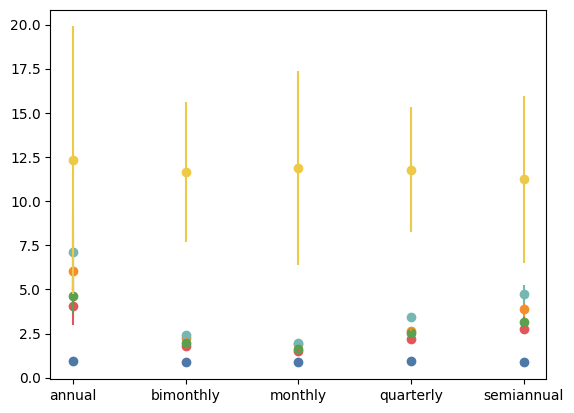

In [220]:
fig = plt.figure()
ax = fig.add_subplot(111)
counter = -1
 
for i in results.keys():
    #Okay - pull the cadence values: 
    xvar = results[i]['measurement cadence']
    #pull the emission object: 
    ems = results[i]['emission_results_object']
    
    #color counter: 
    counter = -1
    
    #and loop over: 
    for j in ems.keys():
        lab = j #set the legend value 
        if j.lower() == "null":
            lab = "no LDAR"

        counter += 1
        ax.scatter(xvar, np.mean(ems[j]), label=lab, color=color_set[counter] )  
        # ax.scatter(xvar, np.mean(ems[j])/np.mean(ems['quarterly_ogi']), label=lab, color=color_set[counter] )  
        ax.errorbar(xvar, np.mean(ems[j]), yerr = np.var(ems[j]), color = color_set[counter])
# plt.legend(bbox_to_anchor=(1, 0.72))
# plt.legend()


Hmhmhmhmhm. Okay, I think my effort to read in here is good...but it's not quite right, for flexibility. 

In [305]:
#Start with creating the catch dataframe: 
looped_results = pd.DataFrame(columns = ['program', 'val_avg', 'val_var', 'threshold', 'cadence', 'cadence_days'])
counter = -1

for indx in range(len(subfolders)):

    #split out the info we need from the folder names: 
    split_folder_name = subfolders[indx].split('_')
    threshold = int(split_folder_name[1])
    cadence = split_folder_name[3]
    cadence_days = int(split_folder_name[4])

    #Once you have that subfolder info, pull out the json files within that subfolder: 
    path_to_json = path_to_loop_results + subfolders[indx] + '/'
    json_files = [pos_json for pos_json in os.listdir(path_to_json) if pos_json.endswith('.json')]

    for i in range(len(json_files)):
        read_file = path_to_json + str(json_files[i])
        df = json.load(open(read_file))
    
        # #okay, embedd this in a sneaky way:      
        # if ((indx == 0) and (i == 1)):
        #     loop_results = {}

        # if i == 0: #on the first iteration create the catch file for all iterations. 
        #     em_results = pd.DataFrame(columns=df.keys())
        #     em_results = em_results.drop(columns=['time'])
            

        #okay - individual file loaded; lets loop through each file and grab the average emissions for each LDAR program. 
        for j in df.keys():
            if j.lower() == "time": #skip the time object
                break
            #Calculate the average emissions value and varainace for the full time series for each LDAR Program: 
            avg_em = np.mean(np.array(df[j]['emission timeseries']))
            var_em = np.var(np.array(df[j]['emission timeseries']))

            #Step up the counter: 
            counter += 1 

            #write to location: 
            # temp = pd.DataFrame( {'program':j,'value_avg': avg_em, 'value_var':var_em, 'threshold': threshold, 'cadence':cadence, 'cadence_days': cadence_days})
            looped_results.at[counter, 'program'] = j
            looped_results.at[counter, 'val_avg'] = avg_em
            looped_results.at[counter, 'val_var'] = var_em
            looped_results.at[counter, 'threshold'] = threshold
            looped_results.at[counter, 'cadence'] = cadence
            looped_results.at[counter, 'cadence_days'] = cadence_days

            # temp = pd.DataFrame([j, avg_em, var_em, threshold, cadence, cadence_days])
           

            # #Okay, create a dictionary object:
            # temp_dict = {'program':j,'value_avg': avg_em, 'value_var':var_em, 'threshold': threshold, 'cadence':cadence, 'cadence_days': cadence_days}
            # print(temp_dict)
    

Change a couple of those columns to a catagory type: https://stackoverflow.com/questions/28910851/python-pandas-changing-some-column-types-to-categories

In [306]:
# for col in ['program', 'cadence']:
#     looped_results[col] = looped_results[col].astype('category')

looped_results['program'] = looped_results['program'].astype('category')
looped_results['cadence'] = looped_results['cadence'].astype('category')



Check the dtypes of the dataframe: 

In [307]:
looped_results.dtypes

program         category
val_avg           object
val_var           object
threshold         object
cadence         category
cadence_days      object
dtype: object

Okay, I had to fiddle artound with this a BUNCH to get matplotlib to do colors for strings; eventually settled on seaborn plots, which feel a lot like a version of ggplot. Nice looking plots too. 

<Axes: xlabel='cadence_days', ylabel='val_avg'>

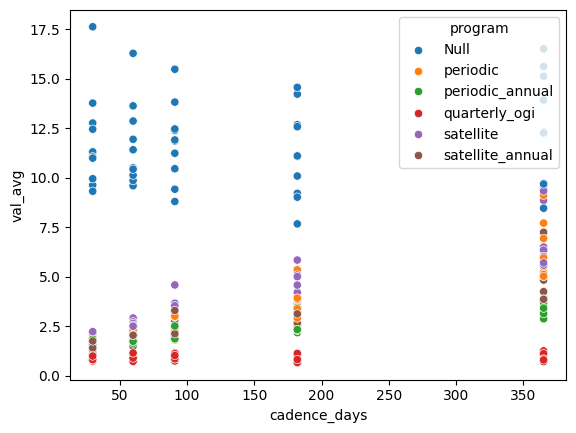

In [308]:
import seaborn as sns

sns.scatterplot(data = looped_results, x = 'cadence_days', y = 'val_avg', hue = 'program')


# ax.scatter(looped_results['cadence_days'], looped_results['val_avg'], c = colors, cmap = 'Set1')

Lets try that reordering the x axis manually - had to go back trhrough and make cadence and program into catagories. Took a bit, here;s the tutoria. https://pandas.pydata.org/docs/user_guide/categorical.html#reordering

In [319]:
reordered = ['monthly', 'bimonthly', 'quarterly', 'semiannual', 'annual']
looped_results['cadence'] = looped_results['cadence'].cat.reorder_categories(reordered, ordered = True)

reordered_programs = ['quarterly_ogi', 'periodic', 'periodic_annual', 'satellite', 'satellite_annual', 'Null']
looped_results['program'] = looped_results['program'].cat.reorder_categories(reordered_programs, ordered = True)


In [317]:
print(looped_results['cadence'])

0          annual
1          annual
2          annual
3          annual
4          annual
          ...    
295    semiannual
296    semiannual
297    semiannual
298    semiannual
299    semiannual
Name: cadence, Length: 300, dtype: category
Categories (5, object): ['monthly' < 'bimonthly' < 'quarterly' < 'semiannual' < 'annual']


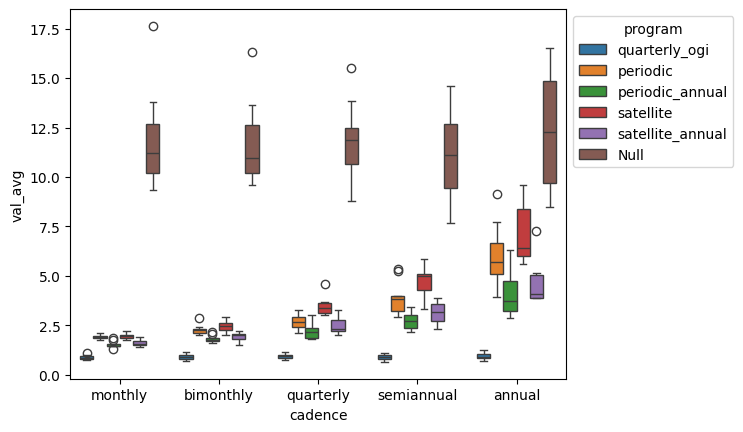

In [320]:
ax = sns.boxplot(data = looped_results, x = 'cadence', y = 'val_avg', hue = 'program')
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1,1))

Lets flip that and do a version where we organize by the LDAR programs. 

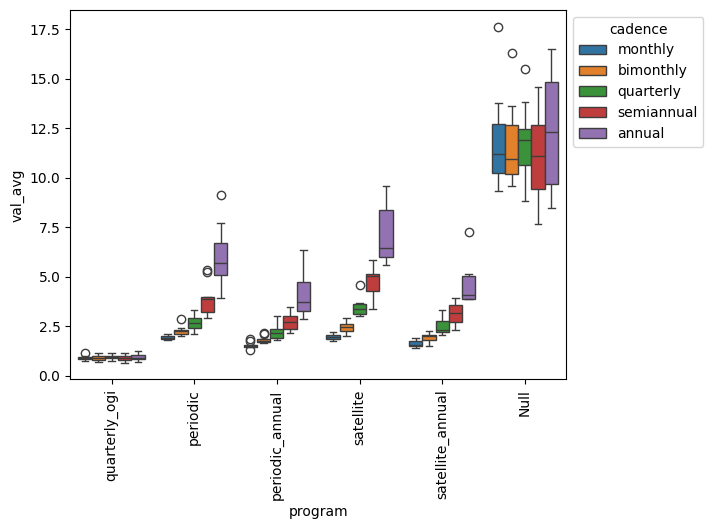

In [324]:
ax = sns.boxplot(data = looped_results, x = 'program', y = 'val_avg', hue = 'cadence')
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1,1))
ax.xaxis.set_tick_params(rotation=90)

AWESOME. okay - these look fantastic, I need to formalize the code out of this, but that's a very nice little workup from the material. This will be easy enough to adaprt to all sorts of programs. That said, there are absoltuely some systemic issues in the LDAR progranms; There is no reason that the satellite programs should be higher than the periodic programs; the only difference there should be that we're calling an additional survey, but clearly that's not exactly what's going on. 
Also, I need to adjust this so that we're only pulling the last year's worth of data, this is all 5 years. 